In [1]:
from torchvision.datasets import MNIST
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import numpy as np
import math


from helpers import *
from loss_and_eval import *
from optim import *
from cnn import *

In [2]:
np.random.seed(42)


train = MNIST(root="data", train=True, download=True)
test = MNIST(root="data", train=False, download=True)

x_train, y_train = [], []
x_test, y_test = [], []

for image, label in train:
    x = np.reshape([pixel / 255.0 for pixel in image.getdata()], shape=(1, 28, 28))
    y = np.zeros(shape=10)
    y[label] = 1.0

    x_train.append(x)
    y_train.append(y)


for image, label in test:
    x = np.reshape([pixel / 255.0 for pixel in image.getdata()], shape=(1, 28, 28))
    y = np.zeros(shape=10)
    y[label] = 1.0

    x_test.append(x)
    y_test.append(y)

x_val = x_train[50000:]
y_val = y_train[50000:]

x_train = x_train[:50000]
y_train = y_train[:50000]

/tmp/ipykernel_115304/332717515.py:11: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  x = np.reshape([pixel / 255.0 for pixel in image.getdata()], shape=(1, 28, 28))
/tmp/ipykernel_115304/332717515.py:20: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  x = np.reshape([pixel / 255.0 for pixel in image.getdata()], shape=(1, 28, 28))


  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 1 | Loss: 1.3365 | Acc: 87.60%


<Figure size 640x480 with 0 Axes>

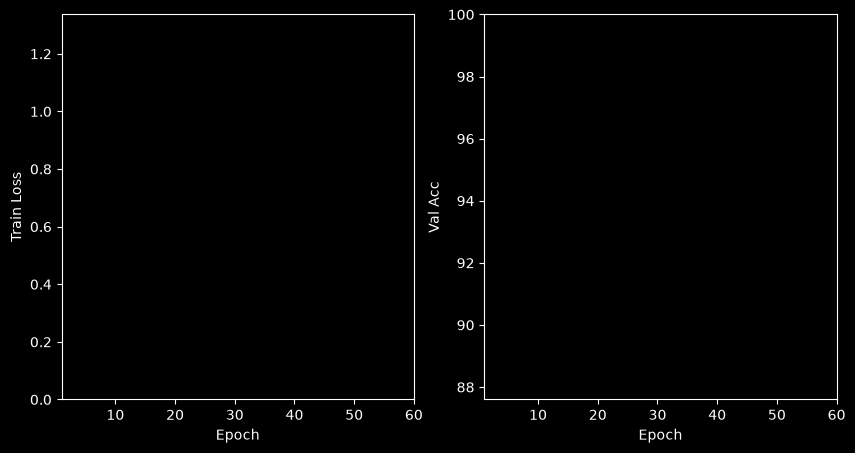

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 2 | Loss: 0.4419 | Acc: 90.61%


<Figure size 640x480 with 0 Axes>

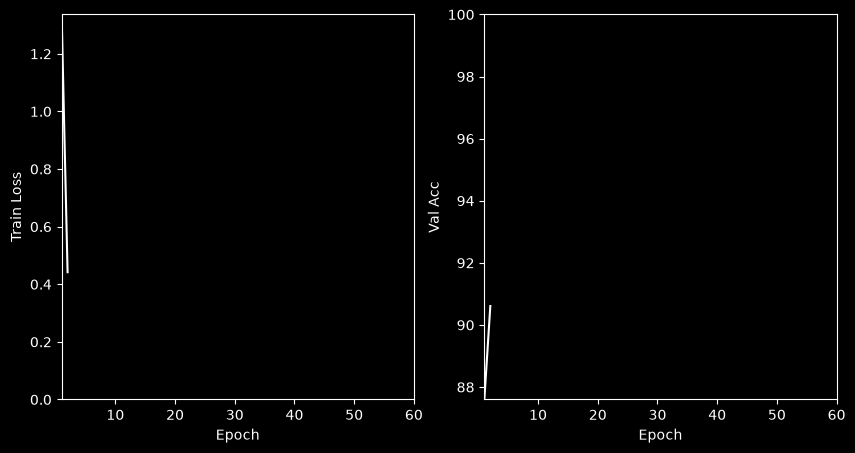

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 3 | Loss: 0.3415 | Acc: 91.91%


<Figure size 640x480 with 0 Axes>

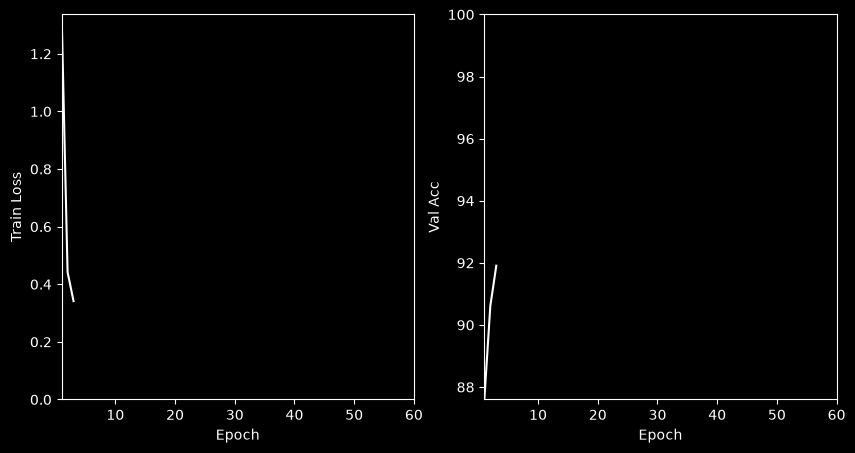

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 4 | Loss: 0.2954 | Acc: 93.07%


<Figure size 640x480 with 0 Axes>

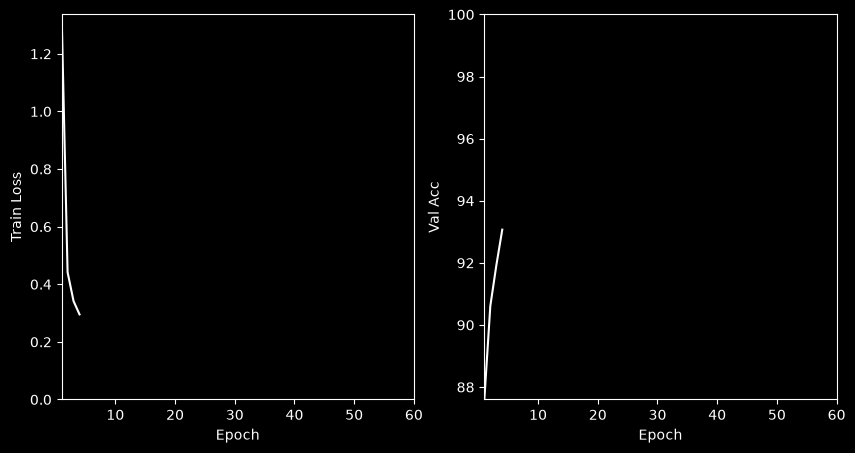

  0%|          | 0/50000 [00:00<?, ?samples/s]

In [ ]:
batch_size = 10
num_filters = [20]
epochs = 60
lr = 1e-2
weight_decay = 0

model = CNN(batch_size, num_filters)


optim = OptimizerNP(lr=lr, batch_size=batch_size, weight_decay=weight_decay)

train_losses = []
val_accs = []
epochs_list = []


for i in range(epochs):
    num_train_samples = len(x_train)
    train_loss = 0.0

    combined = list(zip(x_train, y_train))
    np.random.shuffle(combined)
    x_train, y_train = zip(*combined)

    pbar = tqdm(total=num_train_samples, unit="samples")

    for start in range(0, num_train_samples, batch_size):
        end = start + batch_size

        # x: (batch_size, 1, 28, 28)
        x, y = np.stack(x_train[start:end]), np.stack(y_train[start:end])
        preds = model(x)
        model.backward(y)
 
        loss = batch_NLL(y, preds)
        train_loss += loss

        # if s % 1024 == 0: print(loss)
        pbar.update(batch_size)
        # if (s % 1000 == 0): print(f"{s}/{num_samples}")

        model.step(optim)
        model.clear_grad()


    pbar.close()

    train_loss += L2(model, optim) # L2 Regularization
    train_loss /= num_train_samples

    correct = 0.0
    num_val_samples = len(x_val)

    for start in range(0, num_val_samples, batch_size):
        end = start + batch_size
        x, y = np.stack(x_val[start:end]), np.stack(y_val[start:end])

        preds = model(x)
        correct += acc(y, preds)    

    val_acc = 100 * correct / num_val_samples   
        
    train_losses.append(train_loss)
    val_accs.append(val_acc)
    epochs_list.append(i+1)

    
    print(f"Epoch: {i+1} | Loss: {train_loss:.4f} | Acc: {val_acc:.2f}%")  

    plt.clf()
    plt.style.use("dark_background")
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.axis([1, epochs, 0, max(train_losses)])
    plt.plot(epochs_list, train_losses, c = "white")
    plt.xlabel("Epoch")
    plt.ylabel("Train Loss")

    plt.subplot(1, 2, 2)
    plt.axis([1, epochs, min(val_accs), 100])
    plt.plot(epochs_list, val_accs, c = "white")
    plt.xlabel("Epoch")
    plt.ylabel("Val Acc")

    plt.show()

 

